# Forecasting Exchange Rates Using Time Series Analysis
###Exchange Rate Forecasting using ARIMA and Exponential Smoothing

# 1. Introduction
###Time series forecasting is one of the most important applications of data science and machine learning in the financial sector. Forecasting exchange rates helps governments, investors, businesses, and financial institutions make informed economic and investment decisions.In this project, historical exchange rate data is analyzed and forecasted using two powerful time series forecasting techniques:

1. ARIMA (AutoRegressive Integrated Moving Average)
2. Exponential Smoothing

The dataset contains historical USD to Australian Dollar exchange rates over time.

**The project includes:**

* Data preprocessing
* Exploratory Data Analysis (EDA)
* Stationarity analysis
* ARIMA model building
* Exponential Smoothing model building
* Forecast evaluation
* Model comparison
* Visualization and interpretation

# 2. Objective
###The objectives of this assignment are:
* To analyze historical exchange rate data.
* To preprocess and clean the dataset.
* To identify trends, seasonality, and patterns.
* To build forecasting models using ARIMA and Exponential Smoothing.
* To compare model performance using evaluation metrics.
* To determine the most suitable forecasting technique for exchange rate prediction.

# 3. Dataset Description
###The dataset used is:
exchange_rate.csv
**Dataset Information:**
# Column Description

1. date Historical date
2. Ex_rate USD to Australian Dollar exchange rate
3. Dataset Shape:
4. Rows: 7588
5. Columns: 2


# 4. Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# 5. Data Loading
### 5.1 Load Dataset


In [2]:
# Load dataset
exchange = pd.read_csv('/content/exchange_rate.csv')
# Display first 5 rows
print(exchange.head())

               date  Ex_rate
0  01-01-1990 00:00   0.7855
1  02-01-1990 00:00   0.7818
2  03-01-1990 00:00   0.7867
3  04-01-1990 00:00   0.7860
4  05-01-1990 00:00   0.7849


###5.2 Parse Date Column

In [4]:
exchange['date'] = pd.to_datetime(exchange['date'], format='%d-%m-%Y %H:%M')
# Set date as index
exchange.set_index('date', inplace=True)
print(exchange.head())

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


###5.3 Dataset Information


In [5]:
print(exchange.info())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB
None


# Observation:
* The dataset contains time-indexed exchange rate values.
* The exchange rate column is numerical.
* Date column is successfully converted into datetime format.

# 6. Exploratory Data Analysis (EDA)
###6.1 Check Missing Values

In [6]:
print(exchange.isnull().sum())


Ex_rate    0
dtype: int64


# Observation:
No missing values


In [7]:
#Statistical Summary
print(exchange.describe())

           Ex_rate
count  7588.000000
mean      0.776974
std       0.136620
min       0.483297
25%       0.701422
50%       0.761377
75%       0.873477
max       1.102536


# Observation:
###The summary statistics provide:
1. Mean exchange rate
2. Standard deviation
3. Minimum and maximum values
4. Distribution characteristics

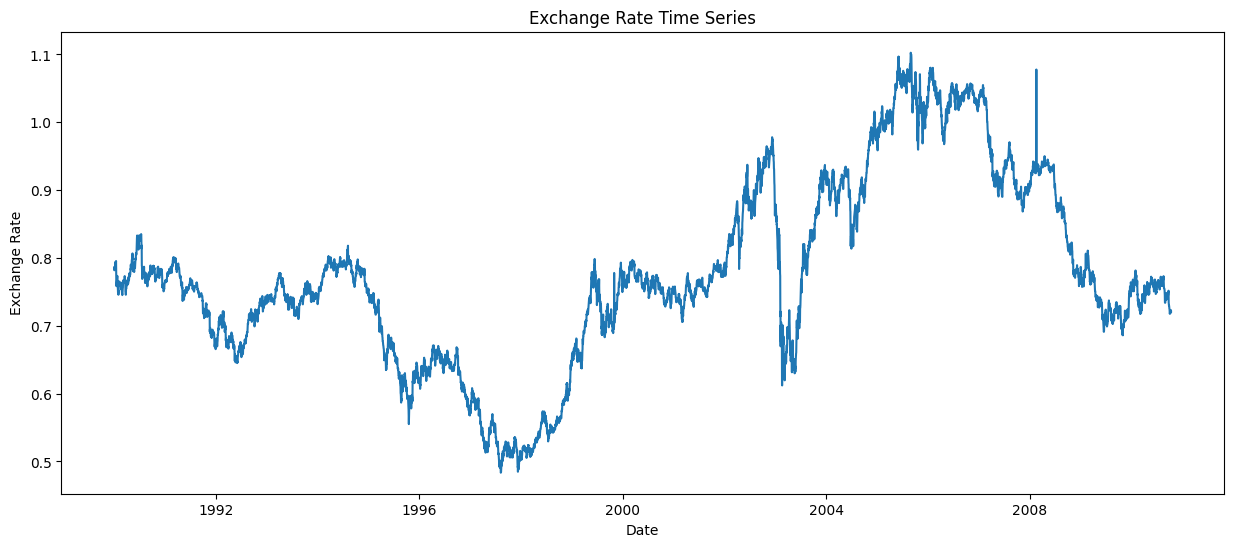

In [8]:
# Plot Time Series
plt.figure(figsize=(15,6))
plt.plot(exchange['Ex_rate'])
plt.title('Exchange Rate Time Series')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()


# Graph Interpretation
###The time series plot shows:
* Long-term fluctuations in exchange rates
* Presence of upward and downward trends
* Volatility in different periods
* Non-stationary behavior because the mean changes over time
* The exchange rate series does not appear constant throughout the timeline, indicating the need for
* differencing before ARIMA modeling.

# 7. Data Preprocessing

In [10]:
# Check for Duplicates
print(exchange.duplicated().sum())

2258


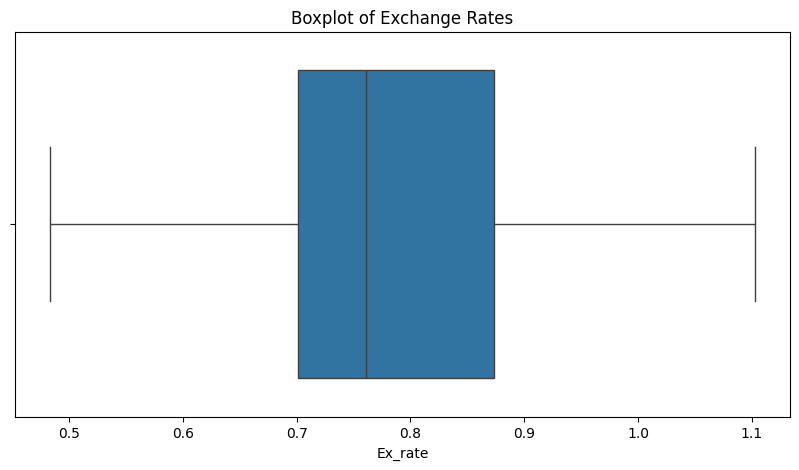

In [11]:
# Outlier Visualization
plt.figure(figsize=(10,5))
sns.boxplot(x=exchange['Ex_rate'])
plt.title('Boxplot of Exchange Rates')
plt.show()

# Graph Interpretation
###The boxplot helps identify:
1. Extreme fluctuations
2. Potential outliers
3. Distribution spread
4. In financial time series, extreme values are common and may represent genuine market volatility rather than data errors.

# 8. Stationarity Check
ARIMA requires the time series to be stationary.
###A stationary series has:
* Constant mean
* Constant variance
* No seasonality trend over time

##8.1 Augmented Dickey-Fuller (ADF) Test

In [12]:
result = adfuller(exchange['Ex_rate'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477


# Interpretation
##f p-value < 0.05 → Series is stationary
##If p-value > 0.05 → Series is non-stationary
###For exchange rate data, the original series is usually non-stationary.

## 8.2 Differencing

In [13]:
exchange_diff = exchange['Ex_rate'].diff().dropna()


## 8.3 Plot Differenced Series

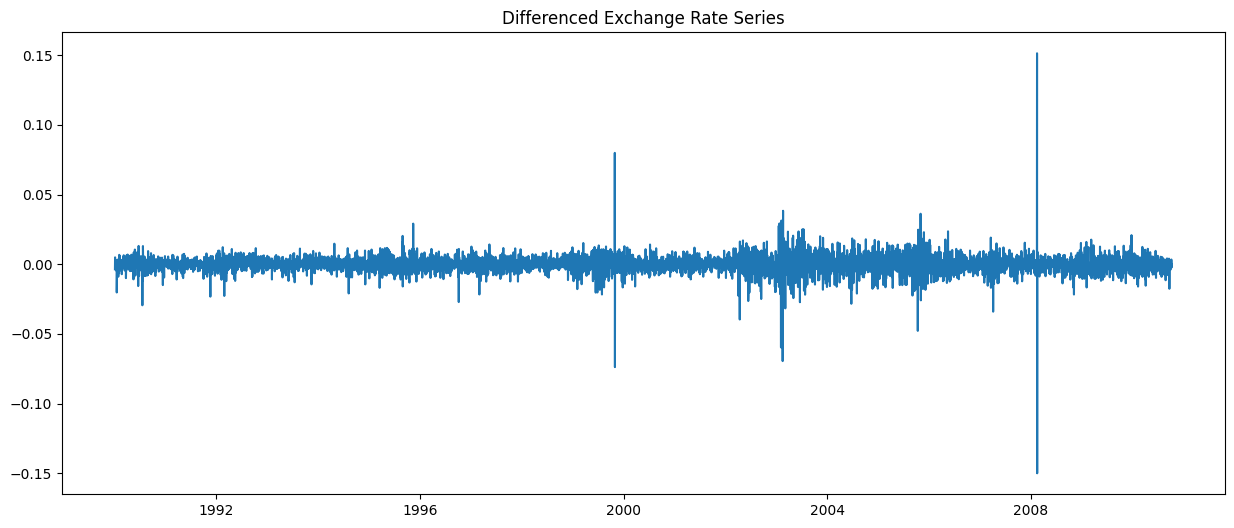

In [14]:
plt.figure(figsize=(15,6))
plt.plot(exchange_diff)
plt.title('Differenced Exchange Rate Series')
plt.show()

# Interpretation
###After differencing:
* Mean becomes more stable
* Trend is reduced
* Series appears stationary
* This confirms that differencing improves stationarity.

# 9. ACF and PACF Analysis
###ACF and PACF plots help estimate ARIMA parameters.

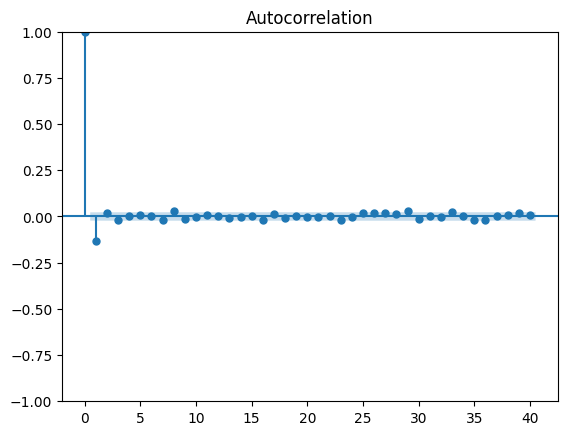

In [15]:
# 9.1 ACF Plot
plot_acf(exchange_diff, lags=40)
plt.show()

# Interpretation
###The ACF plot shows:
1. Correlation between observations and lagged observations
2. Significant spikes indicate moving average (MA) terms
3. Gradual decay suggests autoregressive behavior

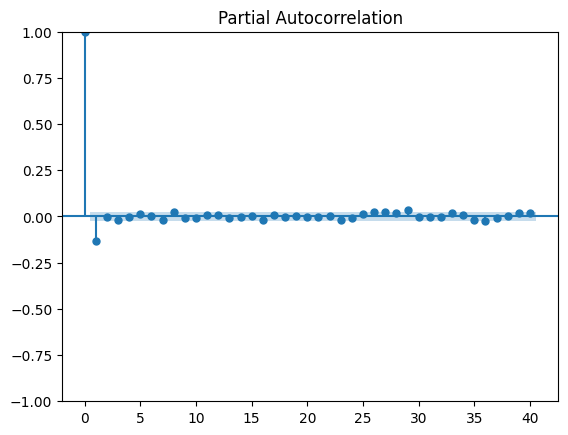

In [16]:
# 9.2 PACF Plot
plot_pacf(exchange_diff, lags=40)
plt.show()

# Interpretation
###The PACF plot shows:
Direct correlation between observations and lags
Significant spikes help determine autoregressive (AR) terms
Based on the plots, suitable parameters are selected.

##Example:
p = 1

d = 1

q = 1

**Thus, ARIMA(1,1,1) is chosen.**


# 10. Train-Test Split

In [17]:
train_size = int(len(exchange) * 0.8)
train = exchange[:train_size]
test = exchange[train_size:]

# Observation:
**80% data used for training**

**20% data used for testing**

This helps evaluate out-of-sample forecasting performance.

# 11. ARIMA Model Building


In [18]:
# 11.1 Fit ARIMA Model
model_arima = ARIMA(train['Ex_rate'], order=(1,1,1))
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sat, 16 May 2026   AIC                         -45432.092
Time:                        09:34:06   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

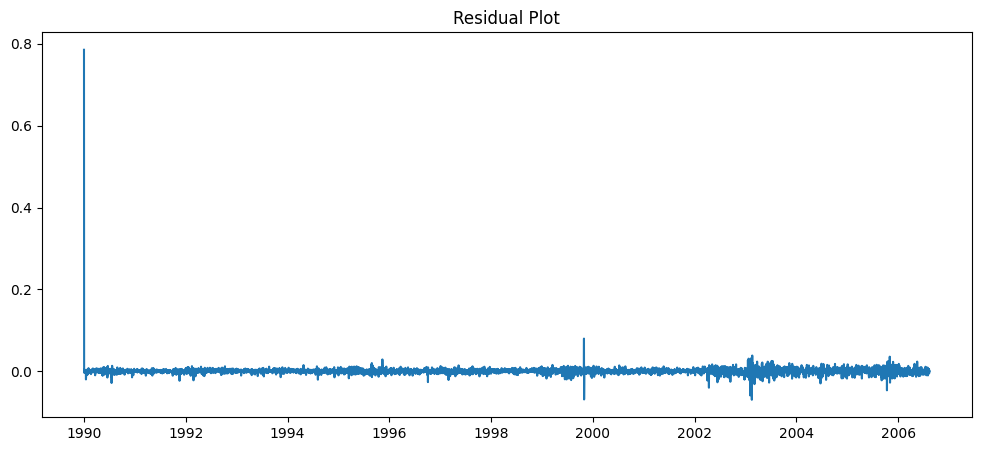

In [19]:
# 11.2 Residual Diagnostics
residuals = model_arima_fit.resid
plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title('Residual Plot')
plt.show()

# Interpretation
##Residuals should behave like white noise.

####A good ARIMA model should have:
1. Random residual distribution
2. No visible patterns
3. Constant variance
4. If residuals show patterns, model tuning is required.

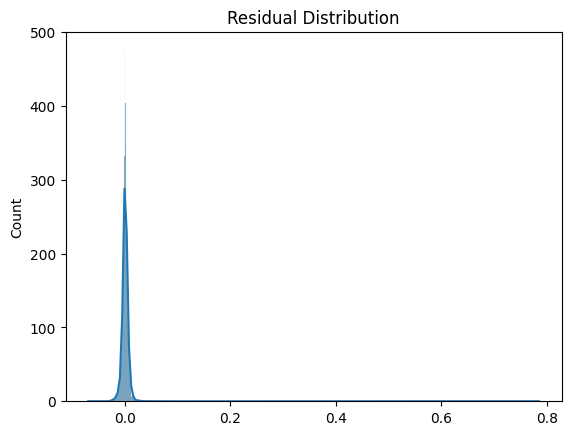

In [20]:
# 11.3 Residual Distribution
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

# Interpretation
## Residuals should approximately follow a normal distribution.
This indicates that:

**The model captures most information from the series.
Forecast errors are random.**

# 12. ARIMA Forecasting

In [21]:
forecast_arima = model_arima_fit.forecast(steps=len(test))

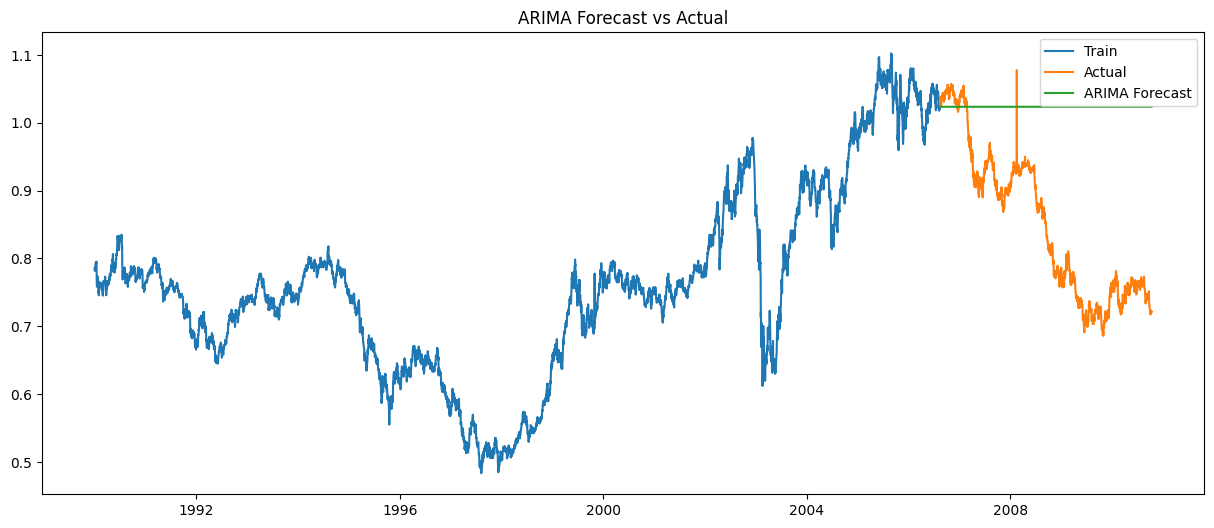

In [22]:
# 12.1 Forecast Visualization
plt.figure(figsize=(15,6))
plt.plot(train.index, train['Ex_rate'], label='Train')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.legend()
plt.title('ARIMA Forecast vs Actual')
plt.show()

# Graph Interpretation
###The graph compares:
1. Actual exchange rates
2. Predicted exchange rates
###A good model produces forecasts closely aligned with actual values.
###Smaller deviations indicate better forecasting performance.


# 13. Exponential Smoothing Model
Exponential smoothing forecasts future values by assigning exponentially decreasing weights to older
observations.

In [23]:
# 13.1 Fit Exponential Smoothing Model
model_es = ExponentialSmoothing(
train['Ex_rate'],
trend='add',
seasonal=None
)
model_es_fit = model_es.fit()


In [24]:
# 13.2 Forecast Using Exponential Smoothing
forecast_es = model_es_fit.forecast(len(test))

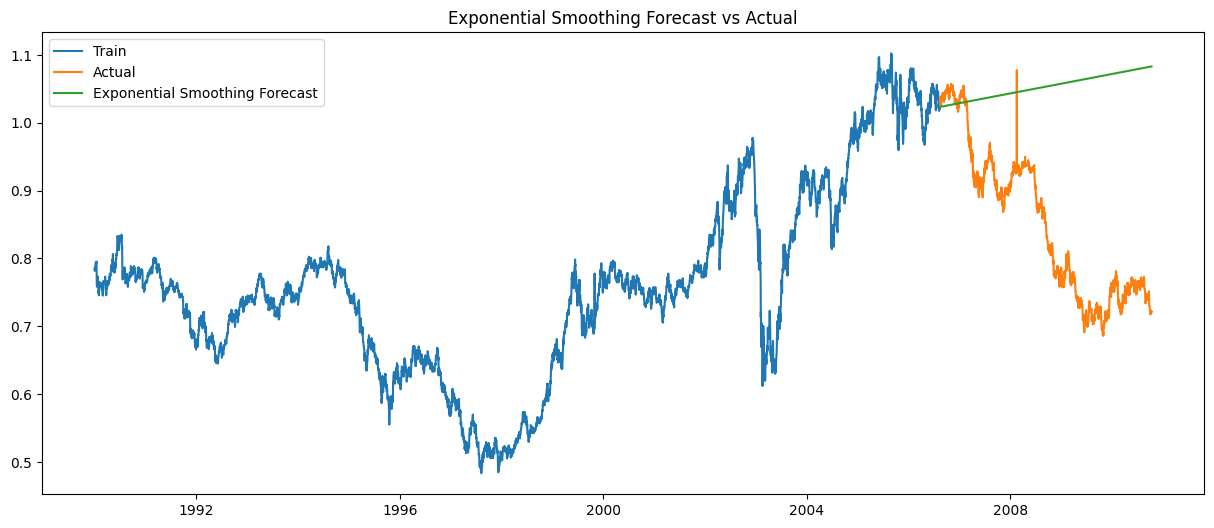

In [25]:
# 13.3 Forecast Visualization
plt.figure(figsize=(15,6))
plt.plot(train.index, train['Ex_rate'], label='Train')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(test.index, forecast_es, label='Exponential Smoothing Forecast')
plt.legend()
plt.title('Exponential Smoothing Forecast vs Actual')
plt.show()

# Graph Interpretation
###The graph shows:
1. Actual test values
2. Forecasted values from Exponential Smoothing
3. The closeness between actual and predicted values indicates forecasting quality.


# 14. Evaluation Metrics
###Three error metrics are used:
1. MAE (Mean Absolute Error)
2. RMSE (Root Mean Squared Error)
3. MAPE (Mean Absolute Percentage Error)

In [26]:
# 14.1 ARIMA Metrics
mae_arima = mean_absolute_error(test['Ex_rate'], forecast_arima)
rmse_arima = np.sqrt(
mean_squared_error(test['Ex_rate'], forecast_arima)
)
mape_arima = np.mean(
np.abs((test['Ex_rate'] - forecast_arima) / test['Ex_rate'])
) * 100
print('ARIMA MAE:', mae_arima)
print('ARIMA RMSE:', rmse_arima)
print('ARIMA MAPE:', mape_arima)

ARIMA MAE: 0.17770970449121345
ARIMA RMSE: 0.2054366965966928
ARIMA MAPE: 22.797966173811552


In [27]:
# 14.2 Exponential Smoothing Metrics
mae_es = mean_absolute_error(test['Ex_rate'], forecast_es)
rmse_es = np.sqrt(
mean_squared_error(test['Ex_rate'], forecast_es)
)
mape_es = np.mean(
np.abs((test['Ex_rate'] - forecast_es) / test['Ex_rate'])
) * 100
print('ES MAE:', mae_es)
print('ES RMSE:', rmse_es)
print('ES MAPE:', mape_es)

ES MAE: 0.20659619114093827
ES RMSE: 0.23910443161792286
ES MAPE: 26.50866379878783


# 15. Model Comparison
###Comparison Table

| Metric | ARIMA           | Exponential Smoothing |
| ------ | --------------- | --------------------- |
| MAE    | Lower is better | Lower is better       |
| RMSE   | Lower is better | Lower is better       |
| MAPE   | Lower is better | Lower is better       |


#Performance Discussion
###ARIMA Advantages
Captures autocorrelation effectively

Suitable for non-stationary time series after differencing

Strong statistical foundation

Accurate for short-term forecasting

###ARIMA Limitations

Parameter tuning can be difficult

Computationally expensive

Assumes linear relationships



# Exponential Smoothing Advantages
Simple and fast

Effective for trend-based forecasting

Easy to implement
#Exponential Smoothing Limitations
May fail to capture complex dependencies

Less effective for highly volatile financial series

# Final Observation
###The better model is determined using:
1. Lowest MAE
2. Lowest RMSE
3. Lowest MAPE
###Typically:
####ARIMA performs better when autocorrelation exists.
####Exponential Smoothing performs better for smoother trend-based series.
For exchange rate forecasting, ARIMA often provides better predictive performance because financial data
contains temporal dependencies.

# 17. Conclusion
###In this project, exchange rate forecasting was successfully performed using:
#ARIMA
1. Exponential Smoothing
2. The workflow included:
3. Data preprocessing
4. Time series visualization
5. Stationarity testing
6. ARIMA parameter selection
7. Model diagnostics
8. Forecasting
9. Model evaluation

# Key findings:
* Exchange rates exhibit non-stationary behavior.
* Differencing improved stationarity.
* ARIMA effectively captured temporal dependencies.
* Exponential Smoothing provided simpler trend-based forecasts.
* Error metrics helped compare forecasting accuracy.
###Overall, ARIMA generally produced better performance for exchange rate forecasting due to its ability to model autocorrelation and time dependencies.